# Cake view: (q, χ) reshape

The *cake* transforms a detector image from pixel coordinates to (q, χ) polar coordinates. Useful for:

- **Strong calibration check** — scattering rings become straight vertical lines if the geometry is right. Curves or tilts = something's off (re-fit the PONI in `pyFAI-calib2`).
- **Visualising preferred orientation** — anisotropic intensity vs χ reveals texture in the sample.
- **Picking sector ranges** for sector integration in [`04_azimuthal_integration.ipynb`](04_azimuthal_integration.ipynb).

In [1]:
import matplotlib.pyplot as plt

from giwaxs_analysis import calibration, io, integration, plotting

## 1. Load the calibration

In [ ]:
PONI_PATH = '../data/calibrant_AgBh.poni'
MASK_PATH = '../data/mask.edf'
CALIBRANT_PATH = '../data/calibrant_AgBh.edf'
SAMPLE_PATH = '../data/insitu/in_situ_GIWAXS_1.edf'

calib = calibration.load_calibration(PONI_PATH, MASK_PATH)
print(calibration.summarise(calib))
frame = io.load_frame(CALIBRANT_PATH)

Pilatus2M  dist=275.7 mm  beam=(209.9, 35.8) mm  λ=1.2398 Å  E=10.000 keV  masked=8.0%


## 2. True GIWAXS reshape: (qxy, qz) reciprocal-space map

The polar cake above is just a polar rebin — it ignores sample tilt. For grazing-incidence data the *correct* reshape projects each detector pixel onto reciprocal space accounting for the Ewald-sphere geometry, giving a `(qxy, qz)` map (qxy = in-plane, qz = out-of-plane).

You need to supply the **incidence angle αᵢ** in degrees — typical values are 0.1–0.3°. The "missing wedge" near qz = 0 is expected: that part of reciprocal space isn't accessible from above the sample.

Uses [`pygix`](https://github.com/tgdane/pygix).

q-map shape: (500, 500)  (qz × qxy)
qxy range: -1.36 to 2.99 Å⁻¹
qz range:  -1.39 to 3.07 Å⁻¹


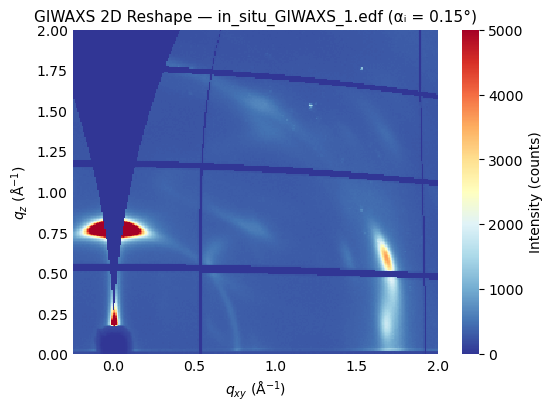

In [21]:
INCIDENCE_ANGLE = 0.15      # grazing angle αᵢ in degrees

# Geometry conventions — flip if your beamline's setup is mirrored
FLIP_QXY = True
FLIP_QZ = True

# Intensity range for the colour scale. None = auto from data.
VMIN = None                 # e.g. 10
VMAX = 5000             # e.g. 5000
LOG_SCALE = False            # ← False for linear colour scale

# q ranges shown on the plot (Å⁻¹).
QXY_RANGE = (-0.25, 2)
QZ_RANGE = (0, 2)

qxy, qz, I_2d_gi = integration.giwaxs_reshape(
    sample_frame, calib,
    incidence_angle=INCIDENCE_ANGLE,
    npt=(500, 500),
    flip_qxy=FLIP_QXY,
    flip_qz=FLIP_QZ,
)
print(f'q-map shape: {I_2d_gi.shape}  (qz × qxy)')
print(f'qxy range: {qxy.min():.2f} to {qxy.max():.2f} Å⁻¹')
print(f'qz range:  {qz.min():.2f} to {qz.max():.2f} Å⁻¹')

fig, ax = plotting.plot_qmap(
    qxy, qz, I_2d_gi,
    vmin=VMIN, vmax=VMAX,
    log=LOG_SCALE,
    qxy_range=QXY_RANGE,
    qz_range=QZ_RANGE,
    title=f'GIWAXS 2D Reshape — {SAMPLE_PATH.rsplit("/", 1)[-1]} (αᵢ = {INCIDENCE_ANGLE}°)',
)
plt.show()